# 08 — XGBoost v2 Baseline (Phase 1)

Refits the same XGBoost hyperparameters from `04_gradient_boosting.ipynb` on the Phase 1 enriched feature set:
- **Geographic features**: `origin_dest_miles`, `shipper_lat/lon`, `recipient_lat/lon`
- **State**: `Recipient State/Province` (one-hot)
- **DAS flag**: `das_type` (one-hot; all-NONE until `data/das_zips.csv` is provided)
- **Decomposed targets**: `log_base_charge`, `log_misc_charge` saved in parquet but not used as features here

Success criteria (Phase 1):
- Validation MAE < \$3.30 (current baseline: \$3.36)
- `origin_dest_miles` appears in top 8 SHAP features for regression
- `models/xgb_classifier_v2.pkl` and `models/xgb_regressor_v2.pkl` save cleanly

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score,
                              mean_absolute_error, mean_squared_error, r2_score)

ROOT = Path.cwd().parent
print('ROOT:', ROOT)

ROOT: /Users/fortnitekorea/Desktop/shipping-dim-xgboost-pytorch


## Load data

In [2]:
train_df = pd.read_parquet(ROOT / 'data' / 'train.parquet')
val_df   = pd.read_parquet(ROOT / 'data' / 'val.parquet')
test_df  = pd.read_parquet(ROOT / 'data' / 'test.parquet')

target_cols = ['dim_flag', 'log_net_charge', 'Net Charge Billed Currency',
               'log_base_charge', 'log_misc_charge']
feature_cols = [c for c in train_df.columns if c not in target_cols]

X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

y_train_cls = train_df['dim_flag']
y_val_cls   = val_df['dim_flag']
y_test_cls  = test_df['dim_flag']

y_train_reg = train_df['log_net_charge']
y_val_reg   = val_df['log_net_charge']

y_val_dollars  = val_df['Net Charge Billed Currency'].values
y_test_dollars = test_df['Net Charge Billed Currency'].values

print(f'Train: {len(X_train):,} rows x {len(feature_cols)} features')
print(f'Val:   {len(X_val):,} rows')
print(f'Test:  {len(X_test):,} rows')
print()

# Show new Phase 1 features
new_features = [c for c in feature_cols if any(k in c for k in
               ['origin_dest', 'shipper_lat', 'shipper_lon', 'recipient_lat',
                'recipient_lon', 'Recipient State', 'das_type'])]
print(f'Phase 1 new features ({len(new_features)}):',
      [f for f in new_features if 'Recipient State' not in f][:10],
      f'... + {sum("Recipient State" in f for f in new_features)} state OHE cols'
      f' + {sum("das_type" in f for f in new_features)} DAS OHE cols')

Train: 45,508 rows x 105 features
Val:   5,688 rows
Test:  5,689 rows

Phase 1 new features (63): ['shipper_lat', 'shipper_lon', 'recipient_lat', 'recipient_lon', 'origin_dest_miles', 'das_type_DAS', 'das_type_EDAS', 'das_type_NONE', 'das_type_REMOTE'] ... + 54 state OHE cols + 4 DAS OHE cols


## XGBoost Classifier v2

Same hyperparameters as v1 (`04_gradient_boosting.ipynb`). Only the feature set changes.

In [3]:
neg_count  = (y_train_cls == 0).sum()
pos_count  = (y_train_cls == 1).sum()
scale_ratio = neg_count / pos_count
print(f'Class balance  neg={neg_count:,}  pos={pos_count:,}  scale_pos_weight={scale_ratio:.3f}')

xgb_clf_v2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_ratio,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

xgb_clf_v2.fit(
    X_train, y_train_cls,
    eval_set=[(X_val, y_val_cls)],
    verbose=False
)

print(f'Best iteration: {xgb_clf_v2.best_iteration}')

Class balance  neg=30,874  pos=14,634  scale_pos_weight=2.110


Best iteration: 40


In [4]:
y_val_pred_clf  = xgb_clf_v2.predict(X_val)
y_val_prob_clf  = xgb_clf_v2.predict_proba(X_val)[:, 1]
y_test_pred_clf = xgb_clf_v2.predict(X_test)
y_test_prob_clf = xgb_clf_v2.predict_proba(X_test)[:, 1]

def cls_metrics(y_true, y_pred, y_prob, label):
    print(f'--- {label} ---')
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'  F1:        {f1_score(y_true, y_pred):.4f}')
    print(f'  ROC AUC:   {roc_auc_score(y_true, y_prob):.4f}')

cls_metrics(y_val_cls,  y_val_pred_clf,  y_val_prob_clf,  'Classifier v2 — Validation')
cls_metrics(y_test_cls, y_test_pred_clf, y_test_prob_clf, 'Classifier v2 — Test')

print()
print('v1 baseline (val):  Accuracy 0.9981 | F1 0.9970 | ROC AUC 0.9997')

--- Classifier v2 — Validation ---
  Accuracy:  0.9979
  Precision: 0.9973
  Recall:    0.9962
  F1:        0.9967
  ROC AUC:   0.9999
--- Classifier v2 — Test ---
  Accuracy:  0.9974
  Precision: 0.9956
  Recall:    0.9962
  F1:        0.9959
  ROC AUC:   0.9997

v1 baseline (val):  Accuracy 0.9981 | F1 0.9970 | ROC AUC 0.9997


## XGBoost Regressor v2

Same hyperparameters as v1. Target: val MAE < \$3.30 (v1 val MAE was \$3.36).

In [5]:
xgb_reg_v2 = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=40,
    random_state=42,
    verbosity=0
)

xgb_reg_v2.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=False
)

print(f'Best iteration: {xgb_reg_v2.best_iteration}')

Best iteration: 439


In [6]:
y_val_pred_log  = xgb_reg_v2.predict(X_val)
y_val_pred_dol  = np.expm1(y_val_pred_log)
y_test_pred_log = xgb_reg_v2.predict(X_test)
y_test_pred_dol = np.expm1(y_test_pred_log)

def reg_metrics(y_true_dol, y_pred_dol, label):
    mae  = mean_absolute_error(y_true_dol, y_pred_dol)
    rmse = np.sqrt(mean_squared_error(y_true_dol, y_pred_dol))
    r2   = r2_score(y_true_dol, y_pred_dol)
    print(f'--- {label} ---')
    print(f'  MAE:  ${mae:.4f}')
    print(f'  RMSE: ${rmse:.4f}')
    print(f'  R²:   {r2:.4f}')
    return mae

val_mae  = reg_metrics(y_val_dollars,  y_val_pred_dol,  'Regressor v2 — Validation')
test_mae = reg_metrics(y_test_dollars, y_test_pred_dol, 'Regressor v2 — Test')

print()
print('v1 baseline (val):  MAE $3.36  RMSE $6.13  R² 0.9049')
print()
if val_mae < 3.30:
    print(f'✓ Phase 1 MAE target met: ${val_mae:.4f} < $3.30')
else:
    print(f'✗ Phase 1 MAE target NOT met: ${val_mae:.4f} >= $3.30')

--- Regressor v2 — Validation ---
  MAE:  $2.5071
  RMSE: $5.6822
  R²:   0.9182
--- Regressor v2 — Test ---
  MAE:  $2.7720
  RMSE: $6.9323
  R²:   0.8884

v1 baseline (val):  MAE $3.36  RMSE $6.13  R² 0.9049

✓ Phase 1 MAE target met: $2.5071 < $3.30


## SHAP Analysis

Check that `origin_dest_miles` appears in the top 8 features for regression (Phase 1 success criterion).

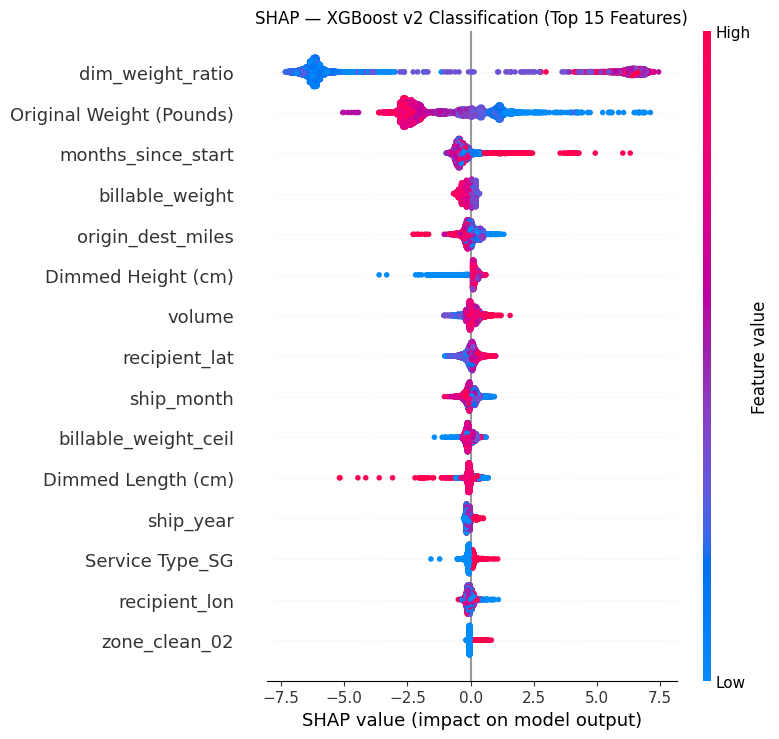

Saved figures/shap_cls_beeswarm_v2.png


In [7]:
# Classification SHAP
explainer_clf = shap.TreeExplainer(xgb_clf_v2)
shap_vals_clf = explainer_clf.shap_values(X_val)

plt.figure()
shap.summary_plot(shap_vals_clf, X_val, max_display=15, show=False)
plt.title('SHAP — XGBoost v2 Classification (Top 15 Features)')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'shap_cls_beeswarm_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/shap_cls_beeswarm_v2.png')

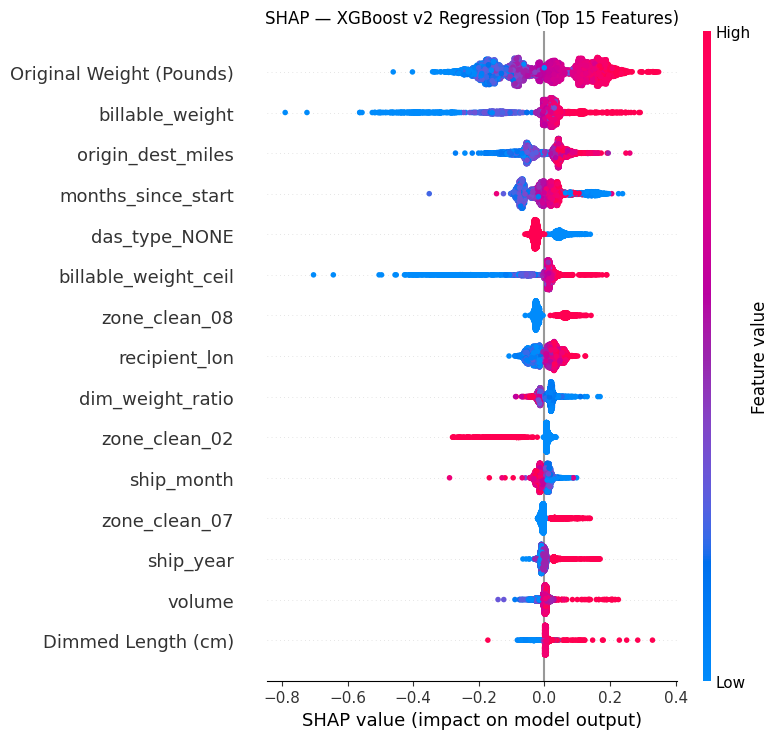

Saved figures/shap_reg_beeswarm_v2.png

Top 8 SHAP features (regression):
  1. Original Weight (Pounds): 0.1224
  2. billable_weight: 0.0583
  3. origin_dest_miles: 0.0550 ← origin_dest_miles
  4. months_since_start: 0.0471
  5. das_type_NONE: 0.0346
  6. billable_weight_ceil: 0.0342
  7. zone_clean_08: 0.0335
  8. recipient_lon: 0.0325

✓ Phase 1 SHAP criterion met: origin_dest_miles is rank 3


In [8]:
# Regression SHAP
explainer_reg = shap.TreeExplainer(xgb_reg_v2)
shap_vals_reg = explainer_reg.shap_values(X_val)

plt.figure()
shap.summary_plot(shap_vals_reg, X_val, max_display=15, show=False)
plt.title('SHAP — XGBoost v2 Regression (Top 15 Features)')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'shap_reg_beeswarm_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/shap_reg_beeswarm_v2.png')

# Check Phase 1 criterion: origin_dest_miles in top 8
mean_abs_shap = pd.Series(
    np.abs(shap_vals_reg).mean(axis=0), index=X_val.columns
).sort_values(ascending=False)

top8 = mean_abs_shap.head(8)
print('\nTop 8 SHAP features (regression):')
for i, (feat, val) in enumerate(top8.items(), 1):
    marker = ' ← origin_dest_miles' if feat == 'origin_dest_miles' else ''
    print(f'  {i}. {feat}: {val:.4f}{marker}')

if 'origin_dest_miles' in top8.index:
    rank = list(mean_abs_shap.index).index('origin_dest_miles') + 1
    print(f'\n✓ Phase 1 SHAP criterion met: origin_dest_miles is rank {rank}')
else:
    rank = list(mean_abs_shap.index).index('origin_dest_miles') + 1
    print(f'\n✗ Phase 1 SHAP criterion NOT met: origin_dest_miles is rank {rank}')

## Save models

In [9]:
joblib.dump(xgb_clf_v2, ROOT / 'models' / 'xgb_classifier_v2.pkl')
joblib.dump(xgb_reg_v2, ROOT / 'models' / 'xgb_regressor_v2.pkl')

# Smoke-test: load and predict one row
clf_loaded = joblib.load(ROOT / 'models' / 'xgb_classifier_v2.pkl')
reg_loaded = joblib.load(ROOT / 'models' / 'xgb_regressor_v2.pkl')

sample = X_test.iloc[[0]]
print('Classifier smoke-test — predicted prob:', clf_loaded.predict_proba(sample)[0, 1])
print('Regressor  smoke-test — predicted charge: $', round(np.expm1(reg_loaded.predict(sample)[0]), 2))
print()
print('Models saved:')
print('  models/xgb_classifier_v2.pkl')
print('  models/xgb_regressor_v2.pkl')

Classifier smoke-test — predicted prob: 0.9996221
Regressor  smoke-test — predicted charge: $ 78.44

Models saved:
  models/xgb_classifier_v2.pkl
  models/xgb_regressor_v2.pkl


## Phase 1 success criteria summary

In [10]:
from pathlib import Path as _P

criteria = {
    'Val MAE < $3.30': val_mae < 3.30,
    'origin_dest_miles in top 8 SHAP (reg)': 'origin_dest_miles' in mean_abs_shap.head(8).index,
    'xgb_classifier_v2.pkl exists': _P(ROOT / 'models' / 'xgb_classifier_v2.pkl').exists(),
    'xgb_regressor_v2.pkl exists':  _P(ROOT / 'models' / 'xgb_regressor_v2.pkl').exists(),
}

print('Phase 1 success criteria:')
all_pass = True
for name, passed in criteria.items():
    symbol = '✓' if passed else '✗'
    print(f'  {symbol} {name}')
    all_pass = all_pass and passed

print()
print('PHASE 1:', 'PASSED' if all_pass else 'FAILED — see above')

Phase 1 success criteria:
  ✓ Val MAE < $3.30
  ✓ origin_dest_miles in top 8 SHAP (reg)
  ✓ xgb_classifier_v2.pkl exists
  ✓ xgb_regressor_v2.pkl exists

PHASE 1: PASSED
